In [1]:
%env HF_HOME=/mnt/LLM
%env CUDA_VISIBLE_DEVICES=3
import torch
import transformers
import gymnasium
import numpy as np
import vizdoom
from typing import Sequence
from vizdoom import gymnasium_wrapper
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline

model_name = "Qwen/Qwen3.6-27B"
processor = transformers.AutoProcessor.from_pretrained(model_name)
tokenizer = processor.tokenizer
model = transformers.AutoModelForMultimodalLM.from_pretrained(
    model_name, torch_dtype="auto", device_map="auto",
).train(False)

def get_logits_processor(model: transformers.PreTrainedModel, suppress_tokens: Sequence[int] = ()):
    """Create a transformers class that post-processes model logits for nucleus sampling, banned tokens, etc"""
    generation_config, model_kwargs = model._prepare_generation_config(model.generation_config)
    model._prepare_special_tokens(generation_config)
    device = next(model.parameters()).device
    return model._get_logits_processor(
        generation_config=generation_config,
        input_ids_seq_length=0,
        encoder_input_ids=None,
        prefix_allowed_tokens_fn=None,
        logits_processor=transformers.LogitsProcessorList([
            transformers.generation.logits_process.SuppressTokensLogitsProcessor(
                suppress_tokens, device=device)]),
        device=device,
        model_kwargs=model_kwargs
    )

env: HF_HOME=/mnt/LLM
env: CUDA_VISIBLE_DEVICES=3


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/1184 [00:00<?, ?it/s]

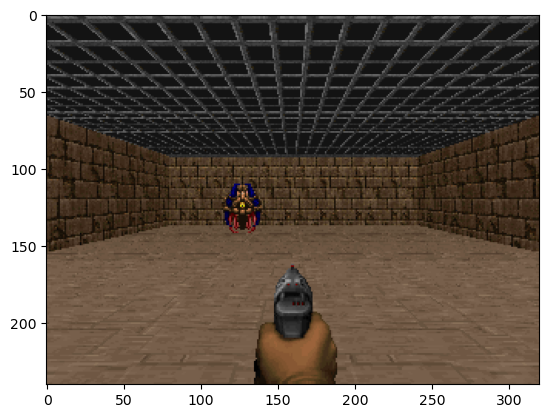

The image shows a first-person view from the game Doom, with the player holding a pistol aimed forward at an enemy (a red demon-like creature) standing in the center of a brick-walled room. The enemy is positioned directly above the gun barrel on the screen, which means it is centered and within firing range according to the given instructions. Since the target is precisely aligned with the weapon’s crosshair area (above the barrel), firing will hit the enemy.

[reasoning interrupted]
#0 [[shoot]]: 0.60156
#1 [[fire]]: 0.13477
#2 [[Shoot]]: 0.05591
#3 [[<|im_end|>]]: 0.04639
#4 [[attack]]: 0.02490
SCORES: nothing: 0.00000, fire: 0.13477, right: 0.00004, left: 0.00048
ACTION: fire 1 r=-10.0, done=False


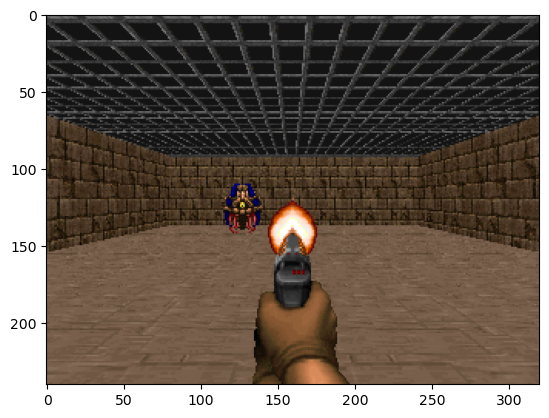

In the image, you are in a first-person view within a Doom game, holding a weapon that is actively firing (indicated by the muzzle flash). There is an enemy directly ahead, centered on the screen and positioned precisely above the gun barrel. According to the instructions, firing works if the enemy is at the center of the screen and precisely above the gun barrel — which matches this scenario. Therefore, continuing to fire is the correct action.

[reasoning interrupted]
#0 [[shoot]]: 0.48242
#1 [[fire]]: 0.12207
#2 [[Shoot]]: 0.07422
#3 [[A]]: 0.03955
#4 [[sh]]: 0.03711
SCORES: nothing: 0.00002, fire: 0.12207, right: 0.00008, left: 0.00056
ACTION: fire 1 r=-5.0, done=False


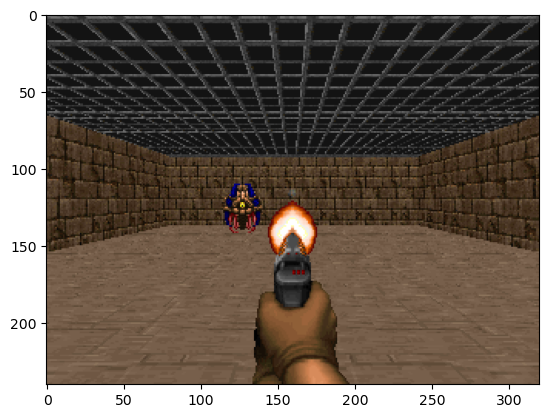

In the image, we are in a first-person view from the game Doom, with a gun barrel visible at the bottom center of the screen. There is an enemy (a blue and red armored figure) positioned directly ahead, slightly to the left of the gun barrel. Since the enemy is not precisely centered above the gun barrel but is instead to the left, firing now would likely miss. According to the instructions, if the enemy is to the left, we should move left to align properly before firing.

[reasoning interrupted]
#0 [[A]]: 0.25781
#1 [[move]]: 0.10059
#2 [[left]]: 0.07373
#3 [[B]]: 0.05737
#4 [[Move]]: 0.05737
SCORES: nothing: 0.00004, fire: 0.03076, right: 0.00185, left: 0.07373
ACTION: left 3 r=-5.0, done=False


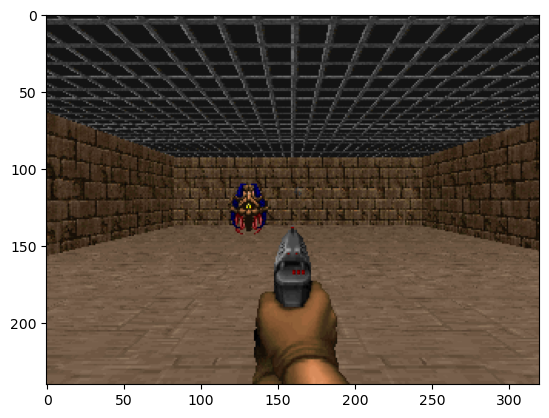

In the image, we are in a first-person perspective within a Doom-like environment, facing an enemy (a pinky demon) positioned slightly to the left of center relative to the gun barrel. The enemy is not precisely aligned above the gun, so firing now would likely miss. According to the instructions, if the enemy is to the left, we should move left to better align for a shot. Therefore, the optimal next action is to adjust position by moving left.

[reasoning interrupted]
#0 [[left]]: 0.20020
#1 [[move]]: 0.17676
#2 [[A]]: 0.15625
#3 [[Move]]: 0.05396
#4 [[B]]: 0.03064
SCORES: nothing: 0.00002, fire: 0.01746, right: 0.00098, left: 0.20020
ACTION: left 3 r=-5.0, done=False


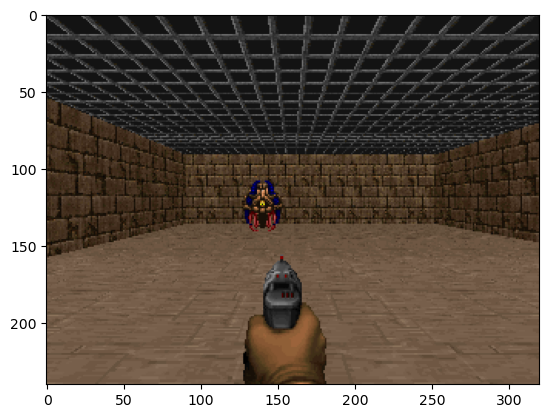

The enemy is positioned slightly to the left of the center of the screen, not directly above the gun barrel. According to the instructions, if the enemy is to the left, you should move left to align yourself before firing. Since the enemy is not centered, firing now would result in a missed shot. Therefore, the best immediate action is to adjust your position by moving left.

[reasoning interrupted]
#0 [[left]]: 0.28516
#1 [[move]]: 0.19629
#2 [[A]]: 0.11865
#3 [[Move]]: 0.07666
#4 [[D]]: 0.03613
SCORES: nothing: 0.00001, fire: 0.01709, right: 0.00159, left: 0.28516
ACTION: left 3 r=-5.0, done=False


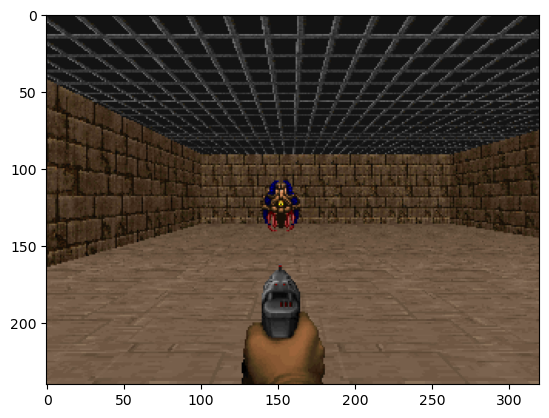

In the image, we see a first-person view from the game Doom. The player is holding a pistol in the lower center of the screen, and directly ahead — precisely centered above the gun barrel — stands an enemy (a Cacodemon). Since the enemy is aligned exactly with the center of the crosshair area (above the weapon), firing will hit the target.

[reasoning interrupted]
#0 [[shoot]]: 0.70312
#1 [[fire]]: 0.07373
#2 [[sh]]: 0.06543
#3 [[attack]]: 0.03955
#4 [[Shoot]]: 0.01990
SCORES: nothing: 0.00000, fire: 0.07373, right: 0.00004, left: 0.00024
ACTION: fire 1 r=96.0, done=False


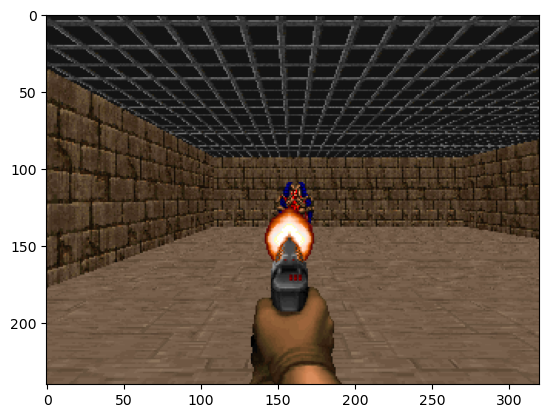

The image shows a first-person view from the game Doom, with the player’s gun barrel centered in the lower portion of the screen. Directly above the gun barrel, an enemy (a blue, pixelated figure) is visible at mid-range, slightly to the right of center. According to the firing rule — “Firing works if the enemy is at the center of the screen, precisely above the gun barrel, otherwise the shot will miss” — the enemy is not perfectly centered; it’s offset to the right. Therefore, to align the crosshair (implied by the gun barrel position) with the enemy, the player should move right to bring the enemy into the center.

[reasoning interrupted]
#0 [[shoot]]: 0.21582
#1 [[A]]: 0.16797
#2 [[fire]]: 0.11572
#3 [[B]]: 0.06592
#4 [[aim]]: 0.05127
SCORES: nothing: 0.00001, fire: 0.11572, right: 0.02136, left: 0.01221
ACTION: fire 1 r=-1.0, done=True


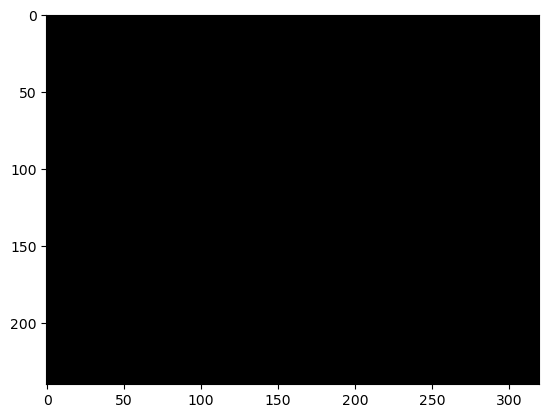

In [4]:
env = gymnasium.make(
    "VizdoomBasic-v1", render_mode="rgb_array", frame_skip=5,
    screen_resolution=vizdoom.ScreenResolution.RES_320X240,
)
obs, *_ = env.reset()
plt.imshow(obs['screen'])
plt.show()

action_names = "nothing", "fire", "right", "left"  # must have distinct first tokens
action_map = {tokenizer.vocab[a]: i for i, a in enumerate(action_names)}
assert len(action_map) == len(action_names)
eos_token_ids = list(model.generation_config.eos_token_id)
logits_processor = get_logits_processor(model)
action_history = []
for i in range(100):
    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": obs["screen"]},
            {"type": "text", "text": """
This is a game of Doom. Which action should I choose next: `nothing`, `fire`, `right`, or `left`? Please use one of these actions, verbatim, with the same capitalization and without extra formatting.
Firing works if the enemy is at the center of the screen, **precisely** above the gun barrel, otherwise the shot will miss. If the enemy is to the right, move right. If it is to the left, move left.
Please analyze the image for one paragraph, then choose the best action code. After the paragraph, write "Best action: `action`", e.g. "Best action: `nothing`".
Do not paraphrase action names, say Best action: `nothing`, `fire`, `right`, or `left` verbatim. The formatting matters: `nothing` is correct, but **not** `Nothing` and not `A) nothing`.
    """.strip()},],},
    ]

    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True, return_dict=True,
        return_tensors="pt", enable_thinking=False
    ).to(model.device)
    
    cache = transformers.DynamicCache(config=model.config)
    with torch.no_grad():
        for i in range(256):
            logits = model(**inputs, use_cache=True, past_key_values=cache).logits[..., -1, :]
            logits = logits_processor(inputs['input_ids'], logits)
            new_token_id = (torch.multinomial(logits.softmax(dim=-1), 1).flatten(
                ) if model.generation_config.do_sample else logits.argmax(-1)).item()
            inputs = dict(input_ids=torch.as_tensor([[new_token_id]], device=model.device))
            new_token = tokenizer.decode(new_token_id)
            print(end=new_token, flush=True)
            if new_token in eos_token_ids or '\n' in new_token:
                break  # stop just short of EOS or new paragraph
    print("[reasoning interrupted]")
    finisher_prompt = "\n\nBest action: `"""
    with torch.no_grad():
        inputs = tokenizer(finisher_prompt, return_tensors='pt', add_special_tokens=False).to(model.device)
        scores = model(**inputs, use_cache=True, past_key_values=cache).logits[..., -1, :].softmax(-1).flatten()
    for i, cand_i in enumerate((-scores).argsort(-1)[:5].tolist()):
        print(f"#{i} [[{tokenizer.decode(cand_i)}]]: {scores[cand_i]:.5f}")
    assert scores.ndim == 1
    action_token_scores = dict(zip(action_map.keys(), scores[list(action_map.keys())].tolist()))
    action_index = action_map[max(action_token_scores, key=action_token_scores.get)]
    obs, r, done, *_etc = env.step(action_index)
    action_history.append(action_index)
    print("SCORES:", ", ".join(f"{a}: {action_token_scores[tokenizer.vocab[a]]:.5f}" for a in action_names))
    print("ACTION:", action_names[action_index], action_index, f"{r=}, {done=}")
    plt.imshow(obs['screen'])
    plt.show()
    if done:
        break
